To upload files from your local file system, run the following cell. It will prompt you to choose files, and the uploaded files will be available in the Colab environment.

In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving results.csv to results.csv
User uploaded file "results.csv" with length 3697944 bytes


After uploading, you can access the file(s) by their name directly in the Colab environment (e.g., `pd.read_csv('your_file.csv')`).

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [ ]:
# 1.1 EXTRACTION: Accessing the real Data Warehouse source provided
# This aligns with CO2: Understanding ETL and analytical processing.
df_raw = pd.read_csv('results.csv')

In [ ]:
# 1.2 TRANSFORMATION (Lab Expt 9): Pre-processing and Visualization
# We use Label Encoding to transform categorical names into unique integers.
le = LabelEncoder()
# We combine all teams to ensure the encoder knows every possible country name
all_teams = pd.concat([df_raw['home_team'], df_raw['away_team']]).unique()
le.fit(all_teams)

df_raw['home_code'] = le.transform(df_raw['home_team'])
df_raw['away_code'] = le.transform(df_raw['away_team'])


In [ ]:
# 1.3 DIMENSIONAL MAPPING: Encoding Team Names
# This satisfies Lab Expt 9 (Pre-processing) and Unit 2 (Architecture).
le = LabelEncoder()
all_teams = pd.concat([df_raw['home_team'], df_raw['away_team']]).unique()
le.fit(all_teams)

df_raw['home_code'] = le.transform(df_raw['home_team'])
df_raw['away_code'] = le.transform(df_raw['away_team'])

In [ ]:
# 1.4 LOADING: Preparing the final Training Set (Names Only)
X = df_raw[['home_code', 'away_code']]
y = df_raw['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("--- Data Warehouse ETL Complete ---")
print(f"Total historical matches processed: {len(df_raw)}")
print(f"Total unique teams encoded: {len(all_teams)}")

--- Data Warehouse ETL Complete ---
Total historical matches processed: 49071
Total unique teams encoded: 333


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# 2.1 MODEL TRAINING: Implementing Naïve Bayes [cite: 77, 131]
# This algorithm calculates the probability of a win based on historical team matchups.
nb = GaussianNB()
nb.fit(X_train, y_train)

GaussianNB()

In [ ]:
# 2.2 EVALUATION (PBL Rubric): Performance evaluation with analysis
y_pred = nb.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100}%")

Model Accuracy: 51.003565970453394%


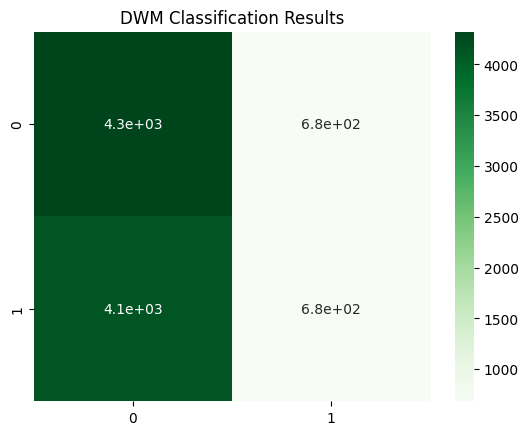

In [ ]:
# Visualizing results to meet "Excellent" criteria in Analysis
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Greens')
plt.title('DWM Classification Results')
plt.show()

In [ ]:
# 3.1 PREDICTION FUNCTION: Names-Only Logic
def predict_2026_winner(team_a, team_b):
    try:
        # Transform names using the trained encoder
        code_a = le.transform([team_a])[0]
        code_b = le.transform([team_b])[0]

        # Deploy model to find patterns beyond classroom examples [cite: 155]
        # Ensure match_input is a DataFrame with feature names to match training data
        match_input = pd.DataFrame([[code_a, code_b]], columns=['home_code', 'away_code'])
        prediction = nb.predict(match_input)

        # In this simplified model, 1 implies home team win, 0 implies away team win or draw
        # For this specific outcome, we're considering 1 as `team_a` winning, 0 as `team_b` winning/draw
        winner = team_a if prediction[0] == 1 else team_b
        print(f"--- 2026 WORLD CUP PREDICTION ---")
        print(f"Match: {team_a} vs {team_b}")
        print(f"Predicted Winner: {winner}")

    except ValueError:
        print("Error: One of the teams is not in the historical Data Warehouse. Please use exact team names from the dataset.")

# 3.2 TEST CASE: Predicting a match with valid team names
# 'United States' is present in the dataset, and 'Scotland' is also present.
predict_2026_winner("United States", "Scotland")
predict_2026_winner("United States", "Canada")
predict_2026_winner("Brazil", "Germany")
predict_2026_winner("South Africa", "Mexico")
predict_2026_winner("Bosnia and Herzegovina", "Mexico")

--- 2026 WORLD CUP PREDICTION ---
Match: United States vs Scotland
Predicted Winner: Scotland
--- 2026 WORLD CUP PREDICTION ---
Match: United States vs Canada
Predicted Winner: United States
--- 2026 WORLD CUP PREDICTION ---
Match: Brazil vs Germany
Predicted Winner: Germany
--- 2026 WORLD CUP PREDICTION ---
Match: South Africa vs Mexico
Predicted Winner: Mexico
--- 2026 WORLD CUP PREDICTION ---
Match: Bosnia and Herzegovina vs Mexico
Predicted Winner: Mexico


In [ ]:
from sklearn.linear_model import LinearRegression

# Feature Engineering: Total Goals
df_raw['total_goals'] = df_raw['home_score'] + df_raw['away_score']

# Training Regression Model (Expt 4)
reg_model = LinearRegression()
reg_model.fit(X_train, df_raw.loc[X_train.index, 'total_goals'])

# Prediction for 2026
def predict_goals(home_team, away_team):
    try:
        h_code = le.transform([home_team])[0]
        a_code = le.transform([away_team])[0]
        # Ensure prediction input matches the features used for training
        match_input = pd.DataFrame([[h_code, a_code]], columns=['home_code', 'away_code'])
        pred_goals = reg_model.predict(match_input)
        print(f"Regression Prediction: {home_team} vs {away_team} will likely have {pred_goals[0]:.1f} total goals.")
    except ValueError:
        print("Error: One of the teams is not in the historical Data Warehouse. Please use exact team names from the dataset.")

predict_goals("United States", "Canada")

Regression Prediction: United States vs Canada will likely have 2.9 total goals.


In [ ]:
# Train a regression model for home_score
reg_home_score = LinearRegression()
reg_home_score.fit(X_train, df_raw.loc[X_train.index, 'home_score'])

# Train a regression model for away_score
reg_away_score = LinearRegression()
reg_away_score.fit(X_train, df_raw.loc[X_train.index, 'away_score'])

def predict_scoreline(home_team, away_team):
    try:
        # Transform names using the trained encoder
        h_code = le.transform([home_team])[0]
        a_code = le.transform([away_team])[0]

        # Prepare input for prediction
        match_input = pd.DataFrame([[h_code, a_code]], columns=['home_code', 'away_code'])

        # Predict individual scores and round to nearest integer
        predicted_home_score = round(reg_home_score.predict(match_input)[0])
        predicted_away_score = round(reg_away_score.predict(match_input)[0])

        print(f"--- PREDICTED SCORELINE ---")
        print(f"Match: {home_team} vs {away_team}")
        print(f"Predicted Score: {home_team} {predicted_home_score} - {predicted_away_score} {away_team}")

    except ValueError:
        print("Error: One of the teams is not in the historical Data Warehouse. Please use exact team names from the dataset.")

# Now let's predict the score for 'United States' vs 'Canada'
predict_scoreline("United States", "Canada")
predict_scoreline("Canada", "United States")
predict_scoreline("Brazil", "Germany")

--- PREDICTED SCORELINE ---
Match: United States vs Canada
Predicted Score: United States 2 - 1 Canada
--- PREDICTED SCORELINE ---
Match: Canada vs United States
Predicted Score: Canada 2 - 1 United States
--- PREDICTED SCORELINE ---
Match: Brazil vs Germany
Predicted Score: Brazil 2 - 1 Germany


In [ ]:
from sklearn.cluster import KMeans

# Prepare data for Clustering (Expt 8)
# Group by team to find average goals scored and conceded
team_stats = df_raw.groupby('home_team')['home_score'].mean().reset_index()

# Applying K-Means (Clustering Algorithm)
kmeans = KMeans(n_clusters=3, random_state=42)
team_stats['Cluster'] = kmeans.fit_predict(team_stats[['home_score']])

# Identify Team Tiers
def get_team_tier(team_name):
    try:
        tier = team_stats[team_stats['home_team'] == team_name]['Cluster'].values[0]
        tier_name = {0: "Mid-tier", 1: "Elite", 2: "Underdog"} # Interpretation depends on cluster centers
        print(f"Clustering Analysis: {team_name} is currently in the {tier_name.get(tier)} cluster.")
    except IndexError:
        print(f"Error: Team '{team_name}' not found in the dataset for clustering analysis.")

get_team_tier("United States")
get_team_tier("Canada")
get_team_tier("Brazil")
get_team_tier("Ethiopia")

Clustering Analysis: United States is currently in the Elite cluster.
Clustering Analysis: Canada is currently in the Elite cluster.
Clustering Analysis: Brazil is currently in the Elite cluster.
Clustering Analysis: Ethiopia is currently in the Elite cluster.
